# 2D Guided-Drift Mechanistic Sandbox

Replace the learned high-dimensional prior with a fully analytic 2D GMM so every quantity
(density, score, geometry) is interpretable and controllable.

Uses properly interleaved experiment sequences (`make_high_diversity_sequences`)
with ~50% repetition rate, matching the real experimental design.

**Sections:**
1. GMM prior definition + visualization
2. Validation checks (score finite-diff, adapter shapes)
3. Sequence generation (transparent)
4. Single-run trial-level diagnostics (score distributions for repeats vs non-repeats)
5. Monte Carlo aggregation (unfolded d' computation)
6. Performance vs encoding noise (sigma0) at ISI=0
7. 2x3 parameter sweep grid (drift_step vs sigma, across sigma0 levels)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from src.model.analytic_gmm_2d import AnalyticGMM2D, make_default_gmm
from src.model.score_adapter_2d import ScoreAdapter2D
from utls.sandbox_2d_data import make_2d_grid_stimuli, compute_geometry_descriptors
from utls.runners_2d import run_model_core_2d
from utls.toy_experiments import make_high_diversity_sequences
from utls.roc_utils import roc_from_arrays, auroc_to_dprime
from utls.analysis_helpers import bootstrap_dprime_ci
from utls.analysis_2d import plot_prior_with_score_field

SAVE_DIR = '../reports/figures/2d_sandbox'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Ready.')

Ready.


## 1. Define the GMM prior and visualise

In [6]:
#defaul parameters
DEFAULT_MEANS = [
    [-2.5, 0.0],   # broad component (centre-left)
    [2.0,  2.0],   # tight component (upper-right)
    [2.0, -2.0],   # tight component (lower-right)
]

DEFAULT_COVARIANCES = [
    [[0.9, 0.0], # broad
     [0.0, 0.9]],   
    
    [[0.4, 0.0], # tight
     [0.0, 0.4]],   
    
    [[0.4, 0.0],  # tight
     [0.0, 0.4]],  
]

DEFAULT_WEIGHTS = [1./3., 1./3., 1./3.]


gmm = make_default_gmm()

####
### OR IF YOU WANT SPECIFY SOMETHING MORE EXACT
gmm = AnalyticGMM2D(means = DEFAULT_MEANS,
 covariances = DEFAULT_COVARIANCES,
 weights = DEFAULT_WEIGHTS)
## 

print(f'Components: {gmm.K}')
print(f'Means:\n{gmm.means.numpy()}')
print(f'Weights: {gmm.weights.numpy()}')

# Generate stimuli
X0, name_to_idx, stimulus_pool = make_2d_grid_stimuli()
descriptors = compute_geometry_descriptors(X0, gmm)
print(f'\nStimuli: {len(X0)} points')
descriptors.head(10)

Components: 3
Means:
[[-2.5  0. ]
 [ 2.   2. ]
 [ 2.  -2. ]]
Weights: [0.33333333 0.33333333 0.33333333]

Stimuli: 80 points


,point_id,x,y,log_density,score_norm,dist_to_nearest_mean,posterior_entropy
0,pt_00,-4.0,-4.0,-12.970018,4.746669,4.272002,4.288891e-16
1,pt_01,-4.0,-3.0,-9.081129,3.726780,3.354102,3.746004e-16
2,pt_02,-4.0,-2.0,-6.303351,2.777778,2.500000,8.446406e-17
3,pt_03,-4.0,-1.0,-4.636684,2.003084,1.802776,4.898352e-18
4,pt_04,-4.0,0.0,-4.081129,1.666667,1.500000,1.452266e-19
5,pt_05,-4.0,1.0,-4.636684,2.003084,1.802776,4.898352e-18
6,pt_06,-4.0,2.0,-6.303351,2.777778,2.500000,8.446406e-17
7,pt_07,-4.0,3.0,-9.081129,3.726780,3.354102,3.746004e-16
8,pt_08,-4.0,4.0,-12.970018,4.746669,4.272002,4.288891e-16
9,pt_09,-3.0,-4.0,-11.858907,4.479032,4.031129,9.282195e-11


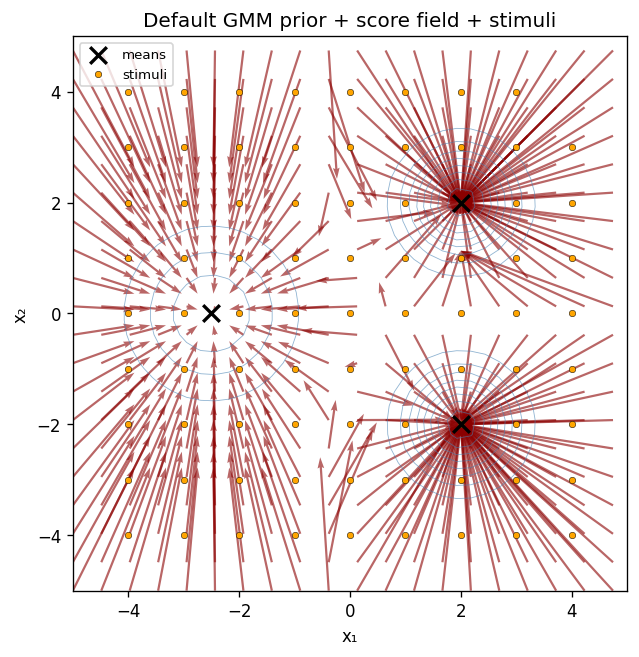

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_prior_with_score_field(gmm, X0=X0, grid_n=40, ax=ax,
                            title='Default GMM prior + score field + stimuli')
fig.savefig(f'{SAVE_DIR}/prior_score_field.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Validation checks

In [8]:
# Finite-difference score verification
eps = 1e-5
rng = np.random.default_rng(42)
max_err = 0.0
for _ in range(20):
    x = torch.tensor(rng.uniform(-4, 4, size=2), dtype=torch.float64)
    analytic = gmm.score(x).numpy()
    numerical = np.zeros(2)
    for d in range(2):
        xp, xm = x.clone(), x.clone()
        xp[d] += eps; xm[d] -= eps
        numerical[d] = (gmm.log_prob(xp).item() - gmm.log_prob(xm).item()) / (2*eps)
    err = np.max(np.abs(analytic - numerical))
    max_err = max(max_err, err)
print(f'Max finite-diff error across 20 points: {max_err:.2e}')
assert max_err < 1e-4, 'Score verification FAILED'

Max finite-diff error across 20 points: 9.56e-10


In [9]:
# Score adapter shape checks
adapter = ScoreAdapter2D(gmm, normalize=True)
s1 = adapter.forward(torch.tensor([1.0, -1.0]))
s2 = adapter.forward(torch.randn(5, 2))
s4 = adapter.forward(torch.randn(3, 1, 1, 2))
print(f'[D] → {s1.shape}, [B,D] → {s2.shape}, [B,1,1,D] → {s4.shape}')
print(f'Unit-norm check: {s2.norm(dim=1).numpy()}')
print('All shape checks passed.')

[D] → torch.Size([2]), [B,D] → torch.Size([5, 2]), [B,1,1,D] → torch.Size([3, 1, 1, 2])
Unit-norm check: [1.         0.99999994 0.99999994 0.9999999  1.        ]
All shape checks passed.


## 3. Sequence Generation (Transparent)

`make_high_diversity_sequences` generates interleaved multi-ISI sequences where:
- Each stimulus appears once (novel/foil) or twice (repeat at a specific ISI lag)
- ~50% repetition rate per sequence
- Each sequence draws from a non-overlapping slice of the stimulus pool

In [10]:
# --- Parameters ---
SIGMA0 = 0.5          # encoding noise
SIGMA = 0.1           # diffusive noise per step
DRIFT_STEP = 0.02     # drift step size (eta)
METRIC = 'euclidean'
ISI_VALUES = (0, 2, 8, 16)
N_SEQUENCES = 10
SEQ_LENGTH = 81
MIN_PAIRS_PER_ISI = 5
N_MC = 5
SEED = 42

# --- Generate sequences ---
experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=list(ISI_VALUES),
    n_sequences=N_SEQUENCES,
    length=SEQ_LENGTH,
    min_pairs_per_isi=MIN_PAIRS_PER_ISI,
    seed=SEED,
)

print(f'Generated {len(experiment_list)} sequences, each length {len(experiment_list[0])}')

# --- Inspect first sequence ---
seq0 = experiment_list[0]
isi0 = isi_keys[0] if isinstance(isi_keys[0], list) else isi_keys

# Count repeats vs novels across all sequences
total_repeats = 0
total_novels = 0
isi_counts = defaultdict(int)

for si, seq in enumerate(experiment_list):
    seen = set()
    for name in seq:
        if name in seen:
            total_repeats += 1
        else:
            total_novels += 1
            seen.add(name)

# Count ISI labels
for isi_seq in (isi_keys if isinstance(isi_keys[0], list) else [isi_keys]):
    for v in isi_seq:
        isi_counts[v] += 1

print(f'\nAcross all sequences:')
print(f'  Novel (first presentation): {total_novels}')
print(f'  Repeat (second presentation): {total_repeats}')
print(f'  Repeat rate: {total_repeats / (total_novels + total_repeats):.1%}')
print(f'\nISI label distribution:')
for k in sorted(isi_counts.keys()):
    label = 'novel/foil' if k == -1 else f'ISI={k}'
    print(f'  {label}: {isi_counts[k]}')

# --- Verify: each repeated item appears exactly twice ---
for si, seq in enumerate(experiment_list):
    from collections import Counter
    counts = Counter(seq)
    max_count = max(counts.values())
    assert max_count <= 2, f'Sequence {si}: item appears {max_count} times!'
print(f'\nVerified: no item appears more than twice in any sequence.')

Aggregate ISI usage across all sequences:
  ISI -1: 270
  ISI 0: 136
  ISI 2: 144
  ISI 8: 152
  ISI 16: 108
Generated 10 sequences, each length 81

Across all sequences:
  Novel (first presentation): 540
  Repeat (second presentation): 270
  Repeat rate: 33.3%

ISI label distribution:
  novel/foil: 270
  ISI=0: 136
  ISI=2: 144
  ISI=8: 152
  ISI=16: 108

Verified: no item appears more than twice in any sequence.


## 4. Single Run — Trial-Level Diagnostics

Run `run_model_core_2d` once to inspect the raw trial-level output:
- Score distributions for repeat (hit) vs novel (FA) trials
- Per-ISI breakdown of hit scores
- d' computed directly from the score distributions

In [11]:
# ISI offset: the runner computes isi = t - last_seen[incoming], which is 1-indexed.
# So experiment ISI=0 -> runner ISI=1, ISI=2 -> runner ISI=3, etc.
runner_isi_values = [isi + 1 for isi in ISI_VALUES]

# Single run with baseline parameters
single_run = run_model_core_2d(
    sigma0=SIGMA0, sigma=SIGMA,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list,
    score_model=adapter,
    drift_step_size=DRIFT_STEP,
    metric=METRIC,
    seed=SEED,
)

print(f'Hit trials (repeats):  {len(single_run["hits"])}')
print(f'FA trials (novels):    {len(single_run["fas"])}')
print(f'\nHit scores by runner ISI:')
for risi in sorted(single_run["isi_hit_dists"].keys()):
    exp_isi = risi - 1
    n = len(single_run["isi_hit_dists"][risi])
    scores = [s for s, t in single_run["isi_hit_dists"][risi]]
    if scores:
        print(f'  ISI={exp_isi:3d} (runner={risi}): {n:4d} trials, '
              f'mean={np.mean(scores):.4f}, std={np.std(scores):.4f}')

# Compute d' per ISI
print(f'\nd\' per ISI (single run):')
score_type = 'distance'  # cosine returns a distance (lower = more similar)
for exp_isi, risi in zip(ISI_VALUES, runner_isi_values):
    hits_raw = single_run["isi_hit_dists"].get(risi, [])
    hits = np.array([s for s, t in hits_raw], dtype=float)
    fas = np.array(single_run["fas"], dtype=float)
    result = roc_from_arrays(hits, fas, score_type=score_type)
    if result is not None:
        _, _, auc_val = result
        dp = auroc_to_dprime(auc_val)
        print(f'  ISI={exp_isi:3d}: AUROC={auc_val:.3f}, d\'={dp:.3f} (n_hits={len(hits)})')
    else:
        print(f'  ISI={exp_isi:3d}: insufficient data')

Hit trials (repeats):  270
FA trials (novels):    530

Hit scores by runner ISI:
  ISI=  0 (runner=1):   68 trials, mean=0.7884, std=0.4625
  ISI=  2 (runner=3):   72 trials, mean=0.7724, std=0.4505
  ISI=  8 (runner=9):   76 trials, mean=0.7971, std=0.4162
  ISI= 16 (runner=17):   54 trials, mean=0.8931, std=0.5793

d' per ISI (single run):
  ISI=  0: AUROC=0.581, d'=0.289 (n_hits=68)
  ISI=  2: AUROC=0.586, d'=0.309 (n_hits=72)
  ISI=  8: AUROC=0.567, d'=0.239 (n_hits=76)
  ISI= 16: AUROC=0.536, d'=0.129 (n_hits=54)


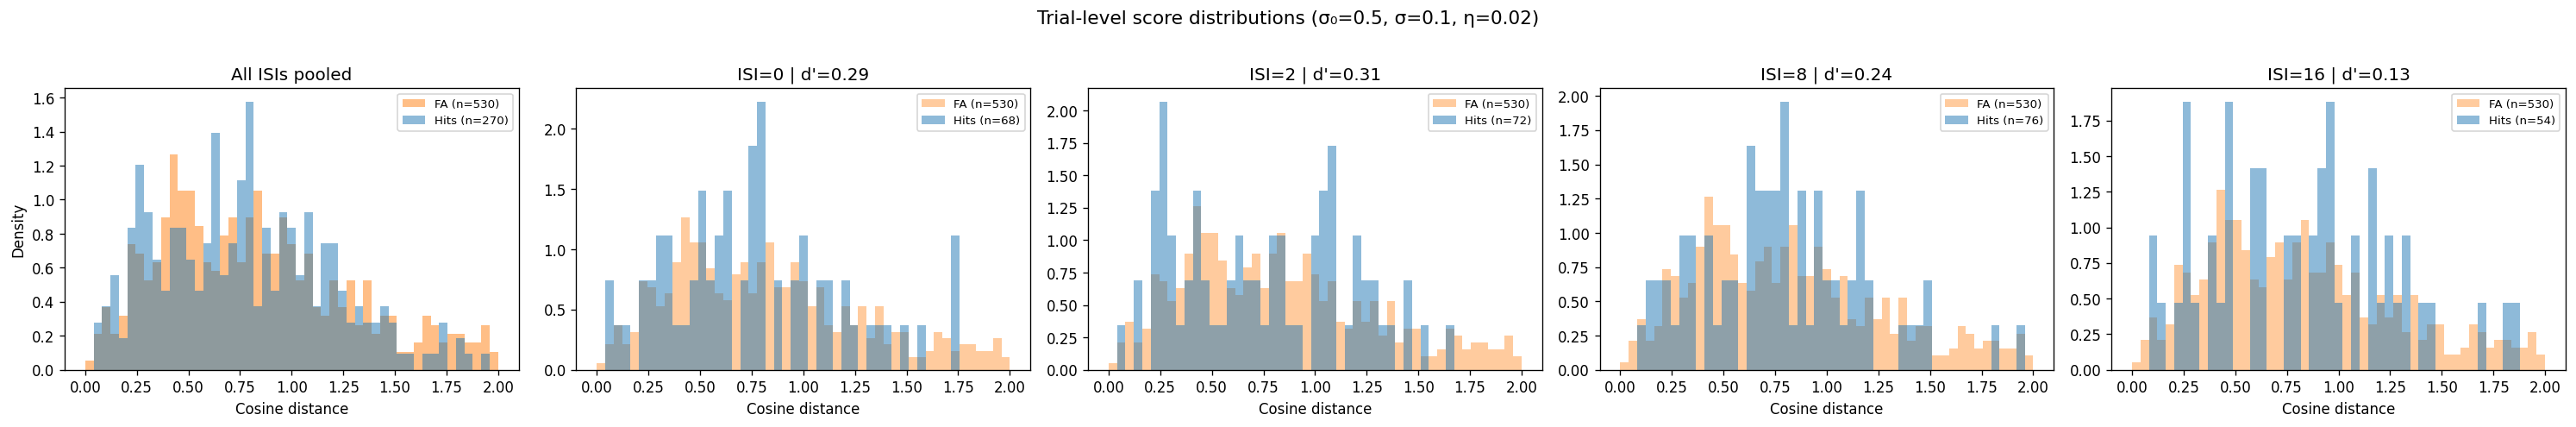

In [12]:
# --- Score distribution plots ---
fas = np.array(single_run["fas"], dtype=float)
bins = np.linspace(0, 2, 50)  # cosine distance range [0, 2]

fig, axes = plt.subplots(1, len(ISI_VALUES) + 1, figsize=(5 * (len(ISI_VALUES) + 1), 4))

# Panel 0: All hits vs all FAs
ax = axes[0]
all_hits = np.array(single_run["hits"], dtype=float)
ax.hist(fas, bins=bins, alpha=0.5, label=f'FA (n={len(fas)})', color='tab:orange', density=True)
ax.hist(all_hits, bins=bins, alpha=0.5, label=f'Hits (n={len(all_hits)})', color='tab:blue', density=True)
ax.set_title('All ISIs pooled')
ax.set_xlabel('Cosine distance')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Panels 1+: Per-ISI hit distributions
for pi, (exp_isi, risi) in enumerate(zip(ISI_VALUES, runner_isi_values)):
    ax = axes[pi + 1]
    hits_raw = single_run["isi_hit_dists"].get(risi, [])
    hits = np.array([s for s, t in hits_raw], dtype=float)

    ax.hist(fas, bins=bins, alpha=0.4, label=f'FA (n={len(fas)})', color='tab:orange', density=True)
    if len(hits) > 0:
        ax.hist(hits, bins=bins, alpha=0.5, label=f'Hits (n={len(hits)})', color='tab:blue', density=True)
        result = roc_from_arrays(hits, fas, score_type='distance')
        if result is not None:
            _, _, auc_val = result
            dp = auroc_to_dprime(auc_val)
            ax.set_title(f'ISI={exp_isi} | d\'={dp:.2f}')
        else:
            ax.set_title(f'ISI={exp_isi}')
    else:
        ax.set_title(f'ISI={exp_isi} (no data)')
    ax.set_xlabel('Cosine distance')
    ax.legend(fontsize=8)

fig.suptitle(f'Trial-level score distributions (σ₀={SIGMA0}, σ={SIGMA}, η={DRIFT_STEP})',
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/trial_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Monte Carlo Aggregation (Unfolded)

Run `run_model_core_2d` multiple times with different seeds, pool hits/FAs across runs,
then compute d' with bootstrap confidence intervals.

This is exactly what `run_2d_isi_sweep` was doing — now fully transparent.

In [13]:
def run_mc_sweep(sigma0, sigma, drift_step_size, score_model, X0, name_to_idx,
                 experiment_list, isi_values, metric='cosine', n_mc=10, seed=42):
    """
    Run Monte Carlo repetitions of run_model_core_2d, aggregate results,
    and compute d' +/- SEM per ISI via bootstrap.

    Returns dict with keys: isi_values, dprime_mean, dprime_sem, auroc, raw_runs
    """
    runner_isi_values = [isi + 1 for isi in isi_values]
    score_type = 'distance' if metric != 'loglikelihood' else 'likelihood'

    # --- MC loop: aggregate hits by ISI, pool FAs ---
    all_isi_hits = defaultdict(list)  # runner_isi -> [(score, t), ...]
    all_fas = []

    for rep in range(n_mc):
        run = run_model_core_2d(
            sigma0=sigma0, sigma=sigma,
            X0=X0, name_to_idx=name_to_idx,
            experiment_list=experiment_list,
            score_model=score_model,
            drift_step_size=drift_step_size,
            metric=metric,
            seed=seed * 10_000 + rep,
        )
        for risi in runner_isi_values:
            all_isi_hits[risi].extend(run["isi_hit_dists"].get(risi, []))
        all_fas.extend(run["fas"])

    all_fas = np.array(all_fas, dtype=float)

    # --- Compute d' per ISI ---
    dprime_mean_list = []
    dprime_sem_list = []
    auroc_list = []

    for exp_isi, risi in zip(isi_values, runner_isi_values):
        hits_raw = all_isi_hits.get(risi, [])
        if len(hits_raw) < 3:
            dprime_mean_list.append(np.nan)
            dprime_sem_list.append(np.nan)
            auroc_list.append(np.nan)
            continue

        hits = np.array([s for s, t in hits_raw], dtype=float)
        result = roc_from_arrays(hits, all_fas, score_type=score_type)
        if result is None:
            dprime_mean_list.append(np.nan)
            dprime_sem_list.append(np.nan)
            auroc_list.append(np.nan)
            continue

        _, _, auc_val = result
        dp_direct = auroc_to_dprime(auc_val)

        # Bootstrap CI
        run_data = {
            "isi_hit_dists": {risi: hits_raw},
            "fas": all_fas,
            "score_type": score_type,
        }
        dp_mean, dp_sem = bootstrap_dprime_ci(run_data, risi, n_boot=200)
        dprime_mean_list.append(dp_mean if np.isfinite(dp_mean) else dp_direct)
        dprime_sem_list.append(dp_sem if np.isfinite(dp_sem) else 0.0)
        auroc_list.append(auc_val)

    return {
        "isi_values": np.array(isi_values),
        "dprime_mean": np.array(dprime_mean_list),
        "dprime_sem": np.array(dprime_sem_list),
        "auroc": np.array(auroc_list),
        "raw_hits": all_isi_hits,
        "raw_fas": all_fas,
    }

METRIC = "euclidean"

# --- Run baseline MC sweep ---
baseline = run_mc_sweep(
    sigma0=SIGMA0, sigma=SIGMA, drift_step_size=DRIFT_STEP,
    score_model=adapter, X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list, isi_values=list(ISI_VALUES),
    metric=METRIC, n_mc=N_MC, seed=SEED,
)

print('Baseline d\' by ISI:')
for isi, dp, sem in zip(baseline["isi_values"], baseline["dprime_mean"], baseline["dprime_sem"]):
    print(f'  ISI={isi:3d}: d\'={dp:.3f} +/- {sem:.3f}')

Baseline d' by ISI:
  ISI=  0: d'=0.208 +/- 0.058
  ISI=  2: d'=0.419 +/- 0.050
  ISI=  8: d'=0.282 +/- 0.051
  ISI= 16: d'=0.227 +/- 0.065


## 6. Performance vs Encoding Noise (sigma0) at ISI=0

How does encoding noise affect discriminability at the shortest lag?
Sweep sigma0 while holding sigma and drift_step fixed.

In [15]:
sigma0_sweep_values = [0.0, 0.1, 0.25, 0.5, 1.0, 1.5, 2.0]
sigma0_dp = []
sigma0_sem = []

for s0 in sigma0_sweep_values:
    result = run_mc_sweep(
        sigma0=s0, sigma=SIGMA, drift_step_size=DRIFT_STEP,
        score_model=adapter, X0=X0, name_to_idx=name_to_idx,
        experiment_list=experiment_list, isi_values=[0],
        metric=METRIC, n_mc=N_MC, seed=SEED + int(s0*1000),
    )
    sigma0_dp.append(result["dprime_mean"][0])
    sigma0_sem.append(result["dprime_sem"][0])
    print(f'  σ₀={s0:.2f}: d\'={result["dprime_mean"][0]:.3f} +/- {result["dprime_sem"][0]:.3f}')

sigma0_dp = np.array(sigma0_dp)
sigma0_sem = np.array(sigma0_sem)

  σ₀=0.00: d'=2.965 +/- 0.065
  σ₀=0.10: d'=1.838 +/- 0.053
  σ₀=0.25: d'=0.703 +/- 0.051
  σ₀=0.50: d'=0.227 +/- 0.053
  σ₀=1.00: d'=-0.014 +/- 0.064
  σ₀=1.50: d'=-0.019 +/- 0.063
  σ₀=2.00: d'=-0.057 +/- 0.065


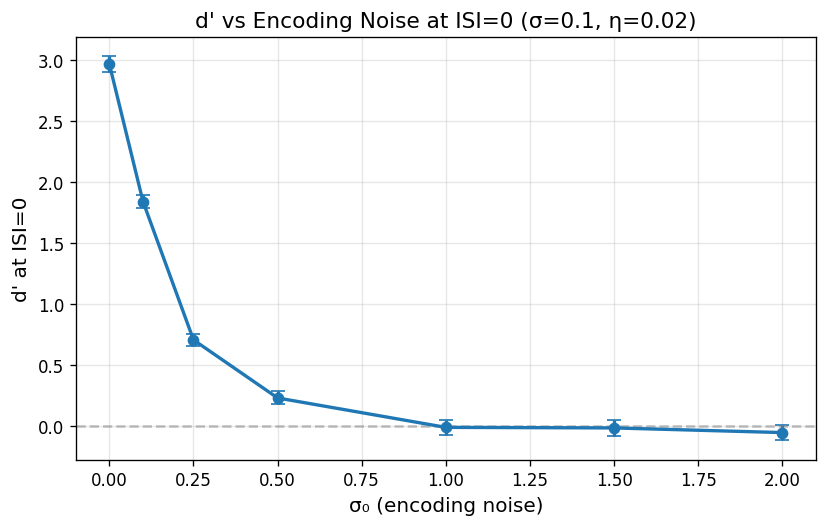

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(sigma0_sweep_values, sigma0_dp, yerr=sigma0_sem,
            marker='o', capsize=4, linewidth=2, color='tab:blue')
ax.set_xlabel('σ₀ (encoding noise)', fontsize=12)
ax.set_ylabel('d\' at ISI=0', fontsize=12)
ax.set_title(f'd\' vs Encoding Noise at ISI=0 (σ={SIGMA}, η={DRIFT_STEP})', fontsize=13)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/dprime_vs_sigma0.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Parameter Sweep: 2×3 Grid (drift_step vs sigma, across sigma0 levels)

For three levels of encoding noise (small, medium, large sigma0):
- **Top row**: Fix sigma, sweep drift_step → how does prior-driven drift affect d' vs ISI?
- **Bottom row**: Fix drift_step, sweep sigma → how does diffusive noise affect d' vs ISI?

ISI values: (0, 2, 16)

In [ ]:
# --- Sweep parameters ---
zero_sigma0, small_sigma0, medium_sigma0, large_sigma0 = 0, 0.1, 0.25, 1
sigma0_levels = {f'zero ({zero_sigma0})': zero_sigma0, f'small ({small_sigma0})': small_sigma0, f'medium ({medium_sigma0})': medium_sigma0, f'large ({large_sigma0})': large_sigma0}
drift_steps_to_sweep = [0.0, 0.02, 0.05, 0.1]
sigmas_to_sweep = [0.0, 0.05, 0.1, 0.3]
FIXED_SIGMA = 0.1
FIXED_DRIFT = 0.02
SWEEP_ISI_VALUES = list(ISI_VALUES)  # (0, 2, 16)

N_MC = 10

# --- Row 1: Fix sigma, sweep drift_step ---
row1_results = {}  # (sigma0_label, drift_step) -> sweep result
for s0_label, s0_val in sigma0_levels.items():
    for eta in drift_steps_to_sweep:
        print(f'Row1: σ₀={s0_val}, σ={FIXED_SIGMA}, η={eta}')
        res = run_mc_sweep(
            sigma0=s0_val, sigma=FIXED_SIGMA, drift_step_size=eta,
            score_model=adapter, X0=X0, name_to_idx=name_to_idx,
            experiment_list=experiment_list, isi_values=SWEEP_ISI_VALUES,
            metric=METRIC, n_mc=N_MC, seed=SEED + int(s0_val*100),
        )
        row1_results[(s0_label, eta)] = res


# --- Row 2: Fix drift_step, sweep sigma ---
row2_results = {}  # (sigma0_label, sigma) -> sweep result
for s0_label, s0_val in sigma0_levels.items():
    for sig in sigmas_to_sweep:
        print(f'Row2: σ₀={s0_val}, σ={sig}, η={FIXED_DRIFT}')
        res = run_mc_sweep(
            sigma0=s0_val, sigma=sig, drift_step_size=FIXED_DRIFT,
            score_model=adapter, X0=X0, name_to_idx=name_to_idx,
            experiment_list=experiment_list, isi_values=SWEEP_ISI_VALUES,
            metric=METRIC, n_mc=N_MC, seed=SEED + int(s0_val*10000),
        )
        row2_results[(s0_label, sig)] = res

print('Done.')

Row1: σ₀=0, σ=0.1, η=0.0


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey='row')
colors_drift = plt.cm.viridis(np.linspace(0.15, 0.85, len(drift_steps_to_sweep)))
colors_sigma = plt.cm.magma(np.linspace(0.15, 0.85, len(sigmas_to_sweep)))

for col, (s0_label, s0_val) in enumerate(sigma0_levels.items()):
    # --- Top row: vary drift_step, fix sigma ---
    ax = axes[0, col]
    for di, eta in enumerate(drift_steps_to_sweep):
        res = row1_results[(s0_label, eta)]
        ax.errorbar(res["isi_values"], res["dprime_mean"], yerr=res["dprime_sem"],
                     marker='o', capsize=3, linewidth=1.5, color=colors_drift[di],
                     label=f'η={eta}')
    ax.set_title(f'σ₀={s0_label}\n(fix σ={FIXED_SIGMA}, vary η)', fontsize=11)
    ax.set_xlabel('ISI')
    if col == 0:
        ax.set_ylabel('d\'', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)

    # --- Bottom row: vary sigma, fix drift_step ---
    ax = axes[1, col]
    for si, sig in enumerate(sigmas_to_sweep):
        res = row2_results[(s0_label, sig)]
        ax.errorbar(res["isi_values"], res["dprime_mean"], yerr=res["dprime_sem"],
                     marker='s', capsize=3, linewidth=1.5, color=colors_sigma[si],
                     label=f'σ={sig}')
    ax.set_title(f'σ₀={s0_label}\n(fix η={FIXED_DRIFT}, vary σ)', fontsize=11)
    ax.set_xlabel('ISI')
    if col == 0:
        ax.set_ylabel('d\'', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)

fig.suptitle('d\' vs ISI: Parameter Sweep Grid', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/parameter_sweep_2x3.png', dpi=150, bbox_inches='tight')
plt.show()